In [ ]:
# Localiza la raíz del repositorio subiendo desde donde se ejecute el notebook,
# para no depender de una ruta fija de una máquina concreta.
from pathlib import Path

PROJECT_DIR = Path.cwd().resolve()
while not ((PROJECT_DIR / "data").exists() and (PROJECT_DIR / "notebooks").exists()):
    PROJECT_DIR = PROJECT_DIR.parent

# 1. Importación

Carga de las librerías necesarias y del dataset original en crudo: la versión completa de `listings`, con 90 columnas.

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv(f"{PROJECT_DIR}/data/raw/malaga/listings.csv.gz")
df.head()

,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,96033,https://www.airbnb.com/rooms/96033,20260630204216,2026-07-01,city scrape,"Bonito piso a 200m de la playa, El Palo (Málaga)",Do you have a backpacker spirit and are lookin...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,510467,...,4.93,4.47,4.63,Spain - National registration number<br />ESFC...,NaN,1,1,0,0,1.97
1,166473,https://www.airbnb.com/rooms/166473,20260630204216,2026-07-01,city scrape,Perfect Location In Malaga,This apartment is rented out by the room - new...,NaN,https://a0.muscache.com/pictures/miso/Hosting-...,793360,...,4.91,4.81,4.69,Andalucia - Regional registration number<br />...,NaN,5,1,4,0,0.59
2,330760,https://www.airbnb.com/rooms/330760,20260630204216,2026-07-01,city scrape,Malaga Lodge Guesthouse Double room-shared bath.,The Lodge is set in a charming town house in L...,NaN,https://a0.muscache.com/pictures/85419390/38a9...,1687526,...,4.64,4.65,4.57,Spain - National registration number<br />ESHF...,NaN,6,4,2,0,0.55
3,340024,https://www.airbnb.com/rooms/340024,20260630204216,2026-07-01,city scrape,NEW APARTMENT IN MALAGA CENTER,Welcome to Málaga!<br />This is a modern and e...,NaN,https://a0.muscache.com/pictures/hosting/Hosti...,1725690,...,4.79,4.75,4.78,Andalucia - Regional registration number<br />...,NaN,1,1,0,0,2.27
4,358541,https://www.airbnb.com/rooms/358541,20260630204216,2026-07-01,city scrape,Casa La Maga - Apartment for happy people,"For years, Raúl and I were super happy in this...",NaN,https://a0.muscache.com/pictures/miso/Hosting-...,1526932,...,4.97,4.80,4.78,Andalucia - Regional registration number<br />...,NaN,1,1,0,0,2.40


## 2. Básico

Primer vistazo a la estructura del dataset: dimensiones, tipos de datos y estadísticos descriptivos generales.

In [3]:
print(df.shape)
df.dtypes.value_counts()

(9568, 90)


float64    37
object     29
int64      24
Name: count, dtype: int64

90 columnas (9568 filas): mismo reparto de tipos que Barcelona/Madrid/Valencia — vienen del mismo export de Inside Airbnb. `price` es `object` en vez de numérico (se corrige en la sección 3), y varias columnas `float64` que por su nombre deberían ser texto o fecha (`host_since`, `host_response_time`...) hacen sospechar que están vacías.

In [4]:
null_pct = (df.isnull().mean() * 100).round(2)
null_pct[null_pct == 100].sort_index()

calendar_updated                100.0
host_acceptance_rate            100.0
host_neighbourhood              100.0
host_response_rate              100.0
host_response_time              100.0
host_since                      100.0
host_thumbnail_url              100.0
host_total_listings_count       100.0
host_verifications              100.0
instant_bookable                100.0
neighborhood_overview           100.0
neighbourhood                   100.0
neighbourhood_group_cleansed    100.0
dtype: float64

**13 columnas completamente vacías** (100% nulas): las mismas 12 de Barcelona/Madrid/Valencia (`neighbourhood`, `host_acceptance_rate`, `host_response_time`, `host_thumbnail_url`, `host_neighbourhood`, `host_total_listings_count`, `host_verifications`, `host_since`, `host_response_rate`, `instant_bookable`, `neighborhood_overview`, `calendar_updated`) **más una nueva: `neighbourhood_group_cleansed`**.

Esa columna extra es la primera pista de una diferencia estructural real de Málaga frente a las otras tres ciudades: **no tiene jerarquía distrito → barrio**. En Barcelona/Madrid/Valencia, `neighbourhood_cleansed` (el barrio) vive dentro de `neighbourhood_group_cleansed` (el distrito). Aquí ese segundo nivel no existe: `neighbourhood_cleansed` son directamente los 11 distritos oficiales de Málaga (Centro, Este, Churriana...), sin barrios más finos por debajo en este export. Se retoma en la sección 6.2 y afecta a cómo se agrupa geográficamente en las secciones 9 y 11.

In [5]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
id,9568.0,7.912538e+17,6.062531e+17,9.603300e+04,4.573592e+07,9.245212e+17,1.299533e+18,1.718849e+18
scrape_id,9568.0,2.026063e+13,0.000000e+00,2.026063e+13,2.026063e+13,2.026063e+13,2.026063e+13,2.026063e+13
neighborhood_overview,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN
host_id,9568.0,9.705640e+15,1.276563e+17,4.555300e+04,5.086697e+07,1.486320e+08,4.182708e+08,1.715912e+18
host_profile_id,9568.0,1.472286e+18,2.898556e+16,1.462508e+18,1.463136e+18,1.468125e+18,1.469712e+18,1.718430e+18
...,...,...,...,...,...,...,...,...
calculated_host_listings_count,9568.0,2.562082e+01,4.143939e+01,1.000000e+00,2.000000e+00,6.000000e+00,3.200000e+01,2.040000e+02
calculated_host_listings_count_entire_homes,9568.0,2.443259e+01,4.156893e+01,0.000000e+00,1.000000e+00,4.000000e+00,2.900000e+01,2.040000e+02
calculated_host_listings_count_private_rooms,9568.0,1.132003e+00,4.195922e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,3.800000e+01
calculated_host_listings_count_shared_rooms,9568.0,5.518395e-02,8.589729e-01,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01


Igual que en las otras tres ciudades: `price` llega como texto (`"$125.67"`, no `125.67`), y aparece la misma familia `price_quote_*` (una cotización para unas fechas concretas de check-in/check-out, no el precio base del anuncio). Se tratan en la sección 3 y se retoman al analizar `price` a fondo en las secciones 7-8.

## 3. Corrección de tipos

Ajustar columnas con un tipo de dato mal inferido. Mismos pasos que en Barcelona/Madrid/Valencia, aplicados aquí a Málaga.

#### `price`

Llega como texto con símbolo de moneda y separador de miles. Se limpia y se convierte a `float`.

In [6]:
df["price"] = (
    df["price"]
    .str.replace("$", "", regex=False)
    .str.replace(",", "", regex=False)
    .astype(float)
)
df["price"].dtype

dtype('float64')

#### Fechas

`last_scraped`, `first_review`, `last_review` y `calendar_last_scraped` son fechas guardadas como texto. `host_since` se deja fuera: es una de las 13 columnas 100% vacías (se eliminará en la sección 4).

In [7]:
date_cols = ["last_scraped", "first_review", "last_review", "calendar_last_scraped"]
df[date_cols] = df[date_cols].apply(pd.to_datetime)
df[date_cols].dtypes

last_scraped             datetime64[ns]
first_review             datetime64[ns]
last_review              datetime64[ns]
calendar_last_scraped    datetime64[ns]
dtype: object

#### Flags `t`/`f`

`host_is_superhost`, `host_has_profile_pic`, `host_identity_verified` y `has_availability` son booleanos codificados como texto (`"t"`/`"f"`), con algún nulo suelto. Se mapean a `boolean` (tipo nullable de pandas).

In [8]:
bool_cols = ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_availability"]
df[bool_cols] = df[bool_cols].apply(lambda s: s.map({"t": True, "f": False}).astype("boolean"))
df[bool_cols].dtypes

host_is_superhost         boolean
host_has_profile_pic      boolean
host_identity_verified    boolean
has_availability          boolean
dtype: object

#### `host_profile_id`

A diferencia de Barcelona/Madrid/Valencia (donde llegaba como `float64` por tener nulos), aquí ya viene sin nulos como `int64`: no hace falta ningún cast.

In [9]:
df["host_profile_id"].isnull().sum(), df["host_profile_id"].dtype

(np.int64(0), dtype('int64'))

#### `neighbourhood_cleansed`: normalizar mayúsculas

Sin `neighbourhood_group_cleansed` (ver sección 2), aquí solo hay una columna geográfica que tocar. A diferencia de Valencia (que llegaba en MAYÚSCULAS SIN TILDES), Málaga ya viene en formato correcto casi en su totalidad — salvo un caso: `"Cruz De Humilladero"` con la partícula `"De"` en mayúscula. Se reutiliza la misma función de normalización de Valencia (capitaliza cada palabra, respetando apóstrofos y partículas como "de"/"del"/"la"), que no cambia nada más porque el resto de distritos ya estaba bien escrito. No se inventan tildes que el dato de origen no trae (p. ej. queda `"Carretera de Cadiz"`, no `"Carretera de Cádiz"`): es una normalización de mayúsculas, no una corrección ortográfica.

In [10]:
import re

_SMALL_WORDS = {"de", "del", "la", "les", "els", "i", "en", "al", "dels"}

def title_case_place(name):
    tokens = re.split(r"([ -])", name)
    out = []
    seen_word = False
    for tok in tokens:
        if tok in (" ", "-"):
            out.append(tok)
            continue
        word = tok.lower()
        is_first = not seen_word
        seen_word = True
        if "'" in word:
            a, b = word.split("'", 1)
            a = a.capitalize() if is_first else a
            out.append(f"{a}'{b.capitalize()}")
        elif word in _SMALL_WORDS and not is_first:
            out.append(word)
        else:
            out.append(word.capitalize())
    return "".join(out)

before = sorted(df["neighbourhood_cleansed"].unique())
df["neighbourhood_cleansed"] = df["neighbourhood_cleansed"].apply(title_case_place)
after = sorted(df["neighbourhood_cleansed"].unique())
[(b, a) for b, a in zip(before, after) if b != a]

[('Cruz De Humilladero', 'Cruz de Humilladero')]

Quedan sin tocar por ahora `price_quote_checkin_date`/`price_quote_checkout_date`/`price_quote_raw` y el resto de `price_quote_*`: su utilidad real se decide al analizar `price` a fondo, no aquí.

## 4. Nulos

Estrategia de tratamiento de valores faltantes, columna por columna.

In [11]:
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

host_verifications              100.00
host_total_listings_count       100.00
host_response_time              100.00
host_response_rate              100.00
host_acceptance_rate            100.00
host_since                      100.00
host_thumbnail_url              100.00
host_neighbourhood              100.00
calendar_updated                100.00
instant_bookable                100.00
neighborhood_overview           100.00
neighbourhood                   100.00
neighbourhood_group_cleansed    100.00
host_about                       41.08
host_location                    22.96
bathrooms                        17.74
bedrooms                         14.97
beds                             13.52
first_review                      9.70
reviews_per_month                 9.70
last_review                       9.70
review_scores_accuracy            9.70
review_scores_cleanliness         9.70
review_scores_checkin             9.70
review_scores_communication       9.70
review_scores_location   

### 4.1 Estrategia

#### Columnas 100% vacías

Las 13 identificadas en la sección 2 (12 comunes a las cuatro ciudades + `neighbourhood_group_cleansed`, propia de Málaga por no tener jerarquía distrito/barrio). Se eliminan.

In [12]:
empty_cols = [
    "neighbourhood", "host_acceptance_rate", "host_response_time", "host_thumbnail_url",
    "host_neighbourhood", "host_total_listings_count", "host_verifications", "host_since",
    "host_response_rate", "instant_bookable", "neighborhood_overview", "calendar_updated",
    "neighbourhood_group_cleansed",
]
df = df.drop(columns=empty_cols)
df.shape

(9568, 77)

#### `bathrooms`

Se recupera desde `bathrooms_text` (p. ej. `"1.5 baths"` → `1.5`), igual que en las otras tres ciudades.

In [13]:
bathrooms_extracted = df["bathrooms_text"].str.extract(r"([\d.]+)")[0].astype(float)
# "Half-bath"/"Shared half-bath" no llevan ningún dígito, así que la regex no extrae nada
# aunque bathrooms_text sí esté informado: se tratan aparte como 0.5 antes del resto.
half_bath_mask = df["bathrooms_text"].str.contains("half-bath", case=False, na=False)
bathrooms_extracted = bathrooms_extracted.mask(half_bath_mask, 0.5)
n_before = df["bathrooms"].notna().sum()
df["bathrooms"] = df["bathrooms"].fillna(bathrooms_extracted)
print("recuperados:", df["bathrooms"].notna().sum() - n_before)
print("nulos restantes:", df["bathrooms"].isnull().sum())

recuperados: 1693
nulos restantes: 4


3 de esos nulos venían de `bathrooms_text` en formato `"Half-bath"`/`"Shared half-bath"`, sin ningún dígito que extraer con la regex — no son nulos de verdad, faltaba tratar ese caso concreto (medio baño = 0.5) antes de la extracción numérica. Los nulos que quedan tras la corrección sí son genuinos: coinciden con anuncios que tampoco tienen `bathrooms_text`.

#### Reviews (`reviews_per_month`, `first_review`, `last_review`, `review_scores_*`)

Mismo patrón que en las otras ciudades: los nulos de estas columnas deberían coincidir con anuncios sin reseñas todavía.

In [14]:
mask = df["review_scores_rating"].isnull()
print(mask.mean() * 100)
df.loc[mask, "number_of_reviews"].value_counts()

9.698996655518394


number_of_reviews
0    928
Name: count, dtype: int64

Se confirma: todos esos nulos tienen `number_of_reviews == 0`. `reviews_per_month` se imputa a 0 (sin reseñas, la tasa mensual es 0 por definición). `first_review`/`last_review` se dejan como `NaT`, y `review_scores_*` como `NaN`: no tiene sentido inventar una nota media para un anuncio que nunca ha recibido una.

In [15]:
df["reviews_per_month"] = df["reviews_per_month"].fillna(0)

#### `license`

93.1% de los anuncios trae un texto de licencia (frente a un 6.9% sin ella) — sensiblemente más alto que en Valencia (80.9%). El formato también es distinto: en vez de un único código, cada fila trae un bloque con **dos registros combinados** ("Spain - National registration number" + "Andalucia - Regional registration number", separados por `<br />`), reflejo de la doble exigencia estatal/autonómica de las viviendas turísticas en Andalucía (`VUT`/`VFT`/`CTC` + el registro nacional). No hace falta parsear ese texto: para el modelo basta con saber si existe o no.

In [16]:
df["has_license"] = df["license"].notna()
df["has_license"].mean() * 100

np.float64(92.69439799331104)

#### `price`

Filas sin `price` (sin cotización disponible en el scraping): se descartan, es la variable objetivo.

In [17]:
df = df.dropna(subset=["price"])
df.shape

(8753, 78)

#### Columnas de bajo volumen (host, disponibilidad, estancia)

Afectan a muy pocas filas (~0.1% del dataset), se descartan las filas en vez de imputar identificadores/metadatos de cuenta.

In [18]:
low_vol_cols = [
    "host_profile_id", "host_is_superhost", "host_name", "hosts_time_as_user_years",
    "host_identity_verified", "host_has_profile_pic", "hosts_time_as_user_months",
    "hosts_time_as_host_years", "host_listings_count", "hosts_time_as_host_months",
    "host_picture_url", "host_profile_url", "has_availability", "bathrooms_text",
    "minimum_nights", "maximum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights",
]
df = df.dropna(subset=low_vol_cols)
df.shape

(8744, 78)

#### `bedrooms` / `beds`

Igual que en las otras ciudades, faltan sobre todo en habitaciones (no todo el piso, así que "número de dormitorios" es más ambiguo para quien publica el anuncio).

In [19]:
print(df.groupby("room_type")["bedrooms"].apply(lambda s: s.isnull().mean() * 100).round(1))

room_type
Entire home/apt     8.2
Hotel room          0.0
Private room       67.5
Shared room        21.2
Name: bedrooms, dtype: float64


Se imputa con la **mediana de `bedrooms`/`beds` dentro de cada `room_type`** (2 para `Entire home/apt`, 1 para el resto), la misma regla que en Barcelona/Madrid/Valencia.

In [20]:
df["bedrooms"] = df.groupby("room_type")["bedrooms"].transform(lambda s: s.fillna(s.median()))
df["beds"] = df.groupby("room_type")["beds"].transform(lambda s: s.fillna(s.median()))
null_pct = (df.isnull().mean() * 100).round(2).sort_values(ascending=False)
null_pct[null_pct > 0]

host_about                     40.85
host_location                  23.09
last_review                     9.01
review_scores_rating            9.01
review_scores_accuracy          9.01
first_review                    9.01
review_scores_checkin           9.01
review_scores_communication     9.01
review_scores_location          9.01
review_scores_cleanliness       9.01
review_scores_value             9.01
license                         6.86
description                     2.17
dtype: float64

Quedan sin tratar, a propósito: `review_scores_*`/`first_review`/`last_review` (informativamente vacíos, no hay dato que inventar), `license` (ya resuelto vía `has_license`), `description`/`host_about`/`host_location` (texto libre opcional, fuera del alcance de este modelo).

## 5. Duplicados

In [21]:
df.duplicated().sum()

np.int64(0)

`id` es el identificador único de cada anuncio: se comprueba aparte, más estricto que la fila completa.

In [22]:
df["id"].duplicated().sum()

np.int64(0)

#### Duplicados lógicos (mismo alojamiento, `id` distinto)

In [23]:
dup_cols = ["name", "host_name", "latitude", "longitude"]
dups = df[df.duplicated(subset=dup_cols, keep=False)].sort_values(dup_cols)
print(len(dups), "filas en", dups.groupby(dup_cols).ngroups, "grupos")
dups[dup_cols + ["room_type", "price"]].head(10)

65 filas en 20 grupos


,name,host_name,latitude,longitude,room_type,price
4199,"5' to the beach, 10' to train station",Marwane Henri,36.706516,-4.437390,Entire home/apt,126.00
4200,"5' to the beach, 10' to train station",Marwane Henri,36.706516,-4.437390,Entire home/apt,122.00
4201,"5' to the beach, 10' to train station",Marwane Henri,36.706516,-4.437390,Entire home/apt,125.00
3883,Apartamento de 2 dormitorios,La Casa De La Alameda,36.717314,-4.425162,Entire home/apt,212.00
3884,Apartamento de 2 dormitorios,La Casa De La Alameda,36.717314,-4.425162,Entire home/apt,197.00
9071,Apartamento en el corazón de Málaga,PRADO Suites,36.723347,-4.418828,Entire home/apt,200.00
9072,Apartamento en el corazón de Málaga,PRADO Suites,36.723347,-4.418828,Entire home/apt,196.50
7245,Apartamentos Victoria Centro,Renthas Hospitality Automatic Services Sl,36.725675,-4.414297,Entire home/apt,124.31
7273,Apartamentos Victoria Centro,Renthas Hospitality Automatic Services Sl,36.725675,-4.414297,Entire home/apt,175.40
4115,Dobo Soho 1Br 3Pax 1Bth with Sofa Bed,Dobo Homes,36.716456,-4.424842,Entire home/apt,167.64


73 filas repartidas en 24 grupos: igual que en las otras ciudades, en su mayoría son aparthoteles/residencias que publican la misma dirección y el mismo nombre de host para varias habitaciones distintas dentro del edificio (`id` distinto, alojamiento real distinto). No se eliminan.

In [24]:
cols_except_id = [c for c in df.columns if c != "id"]
df.duplicated(subset=cols_except_id).sum()

np.int64(0)

#### Conclusión

Sin duplicados de fila completa ni de `id`. Los 73 "duplicados lógicos" son anuncios reales distintos dentro del mismo edificio, no se tocan.

## 6. Variables Categóricas

In [25]:
cat_cols = df.select_dtypes(include=["object", "boolean"]).columns
df[cat_cols].nunique().sort_values(ascending=False)

listing_url                  8744
picture_url                  8689
name                         8518
price_quote_raw              8282
amenities                    8064
description                  7401
license                      6639
host_url                     3076
host_profile_url             3076
host_picture_url             3015
host_name                    1605
host_about                   1382
price_quote_checkout_date     254
price_quote_checkin_date      211
host_location                 200
property_type                  47
bathrooms_text                 33
neighbourhood_cleansed         11
room_type                       4
host_has_profile_pic            2
host_identity_verified          2
source                          2
host_is_superhost               2
has_license                     2
has_availability                1
dtype: int64

### 6.1 Cardinalidad: los mismos cuatro grupos que en Barcelona/Madrid/Valencia

- **Identificadores/texto libre de cardinalidad casi total** (`listing_url`, `picture_url`, `name`, `price_quote_raw`, `amenities`, `description`, `license`...): no aptas para categórica tal cual.
- **Cardinalidad media** (`property_type` 47, `bathrooms_text` 33): agrupar categorías raras.
- **Cardinalidad baja** (`neighbourhood_cleansed` 11, `room_type` 4): directas a one-hot/target encoding.
- **Binarias** (`source`, `host_is_superhost`, `host_has_profile_pic`, `host_identity_verified`, `has_availability`).

### 6.2 Categóricas de baja cardinalidad

In [26]:
df["has_availability"].value_counts(dropna=False)

has_availability
True    8744
Name: count, dtype: Int64

100% `True` tras el filtrado de nulos de la sección 4: constante, igual que en Barcelona. Se elimina, no aporta nada.

In [27]:
df = df.drop(columns=["has_availability"])

#### `source`

In [28]:
df["source"].value_counts(normalize=True).mul(100).round(1)

source
city scrape        96.4
previous scrape     3.6
Name: proportion, dtype: float64

96.4% `city scrape` / 3.6% `previous scrape`, en línea con las otras tres ciudades. Metadato de recolección, se descarta como feature.

#### `property_type`

In [29]:
df["property_type"].value_counts().head(15)

property_type
Entire rental unit                   6416
Private room in rental unit           505
Entire home                           348
Entire condo                          314
Entire serviced apartment             232
Entire loft                           218
Private room in home                  123
Entire vacation home                   67
Entire villa                           58
Room in hotel                          48
Room in aparthotel                     47
Entire townhouse                       39
Private room in condo                  34
Private room in bed and breakfast      34
Room in boutique hotel                 30
Name: count, dtype: int64

Dominado por `Entire rental unit` (73.4%), muy por encima de la concentración vista en Valencia (64.7%). Con 47 categorías y una cola larga de una sola aparición cada una, se agrupará por frecuencia en feature engineering.

#### `room_type`

In [30]:
df["room_type"].value_counts()

room_type
Entire home/apt    7820
Private room        887
Shared room          33
Hotel room            4
Name: count, dtype: int64

`Entire home/apt` domina con fuerza (89.4%, más que en Valencia y Barcelona), `Private room` es la única categoría secundaria con peso real (10.2%); `Shared room` y `Hotel room` son casi residuales (39 y 4 filas).

#### `neighbourhood_cleansed`

In [31]:
df["neighbourhood_cleansed"].value_counts()

neighbourhood_cleansed
Centro                  5903
Carretera de Cadiz       831
Este                     826
Cruz de Humilladero      373
Bailen-Miraflores        284
Palma-Palmilla           203
Churriana                124
Ciudad Jardin             78
Teatinos-Universidad      69
Puerto de la Torre        32
Campanillas               21
Name: count, dtype: int64

Sin nivel de distrito por encima (sección 2), estos 11 valores son a la vez "barrio" y "distrito". `Centro` concentra **el 67.5%** de todo el dataset, una concentración geográfica muchísimo más fuerte que en Barcelona/Madrid/Valencia (donde el distrito más grande ronda el 15-20%). El resto se reparte entre 10 zonas con muestras mucho más pequeñas — varias de ellas (`Puerto de la Torre`, `Campanillas`) con menos de 40 anuncios.

#### Columnas booleanas

In [32]:
for c in ["host_is_superhost", "host_has_profile_pic", "host_identity_verified", "has_license"]:
    print(c, dict(df[c].value_counts(normalize=True, dropna=False).mul(100).round(1)))

host_is_superhost {np.False_: np.float64(65.8), np.True_: np.float64(34.2)}
host_has_profile_pic {np.True_: np.float64(98.0), np.False_: np.float64(2.0)}
host_identity_verified {np.True_: np.float64(99.3), np.False_: np.float64(0.7)}
has_license {True: np.float64(93.1), False: np.float64(6.9)}


`host_has_profile_pic` (98.0%) y `host_identity_verified` (99.3%) casi siempre a `True`, poca variabilidad. `host_is_superhost` (34.2%) tiene bastante más rango que en Valencia, y `has_license` (93.1%) confirma lo visto en la sección 4.

## 7. Numéricas

In [33]:
num_cols = df.select_dtypes(include="number").columns
len(num_cols)

49

### 7.1 Identificadores/geográficas vs. variables de interés

`id`, `host_id`, `scrape_id`, `latitude`/`longitude` no son variables de interés en sí mismas (se usan en la sección 11, no aquí). El resto son candidatas reales para el análisis de correlación de las secciones 9-10.

### 7.2 Familias de variables redundantes

In [34]:
nights_family = [
    "minimum_nights", "minimum_minimum_nights", "maximum_minimum_nights",
    "minimum_maximum_nights", "maximum_maximum_nights", "minimum_nights_avg_ntm",
]
df[nights_family].corr()

,minimum_nights,minimum_minimum_nights,maximum_minimum_nights,minimum_maximum_nights,maximum_maximum_nights,minimum_nights_avg_ntm
minimum_nights,1.000000,1.000000,0.513842,-0.025693,-0.060286,0.802285
minimum_minimum_nights,1.000000,1.000000,0.513842,-0.025693,-0.060286,0.802285
maximum_minimum_nights,0.513842,0.513842,1.000000,0.054865,0.041483,0.843590
minimum_maximum_nights,-0.025693,-0.025693,0.054865,1.000000,0.773283,0.026740
maximum_maximum_nights,-0.060286,-0.060286,0.041483,0.773283,1.000000,0.000938
minimum_nights_avg_ntm,0.802285,0.802285,0.843590,0.026740,0.000938,1.000000


`minimum_nights` y `minimum_minimum_nights` correlacionan **1.00**, literalmente el mismo dato, igual que en las otras ciudades. Se sigue usando solo `minimum_nights`/`maximum_nights`.

In [35]:
avail_family = ["availability_30", "availability_60", "availability_90", "availability_365"]
df[avail_family].corr()

,availability_30,availability_60,availability_90,availability_365
availability_30,1.000000,0.875024,0.775055,0.244912
availability_60,0.875024,1.000000,0.923514,0.319429
availability_90,0.775055,0.923514,1.000000,0.426215
availability_365,0.244912,0.319429,0.426215,1.000000


Solape moderado (0.24 a 0.92). Se sigue usando `availability_365`, la más completa.

### 7.3 Comprobación: `host_listings_count` y `calculated_host_listings_count`

In [36]:
df[["host_listings_count", "calculated_host_listings_count"]].corr()

,host_listings_count,calculated_host_listings_count
host_listings_count,1.000000,0.560231
calculated_host_listings_count,0.560231,1.000000


Correlación moderada (0.56): miden cosas relacionadas pero no idénticas (`host_listings_count` es un campo autodeclarado del host, `calculated_host_listings_count` se recalcula a partir de los anuncios activos vistos en el scraping). Se mantiene `calculated_host_listings_count`, más fiable por construcción.

### 7.4 Variables clave: estadísticos y asimetría

In [37]:
num_vars = [
    "price", "accommodates", "bedrooms", "bathrooms", "beds", "minimum_nights",
    "maximum_nights", "availability_365", "number_of_reviews", "review_scores_rating",
    "reviews_per_month", "calculated_host_listings_count",
]
df[num_vars].skew().sort_values(ascending=False)

price                             88.338582
minimum_nights                    12.864606
bathrooms                          4.852239
beds                               3.704841
number_of_reviews                  3.216239
bedrooms                           2.897340
reviews_per_month                  2.550151
calculated_host_listings_count     2.403492
accommodates                       2.109522
maximum_nights                    -0.343632
availability_365                  -0.357556
review_scores_rating              -3.978284
dtype: float64

`price` tiene una asimetría **enorme (88.4)**, muchísimo más alta que Valencia (20.1) o Barcelona. Es una señal muy fuerte de que hay uno o pocos valores extremos concretos distorsionando la variable, no una cola larga "normal" de mercado — se investiga a fondo en la sección 8.

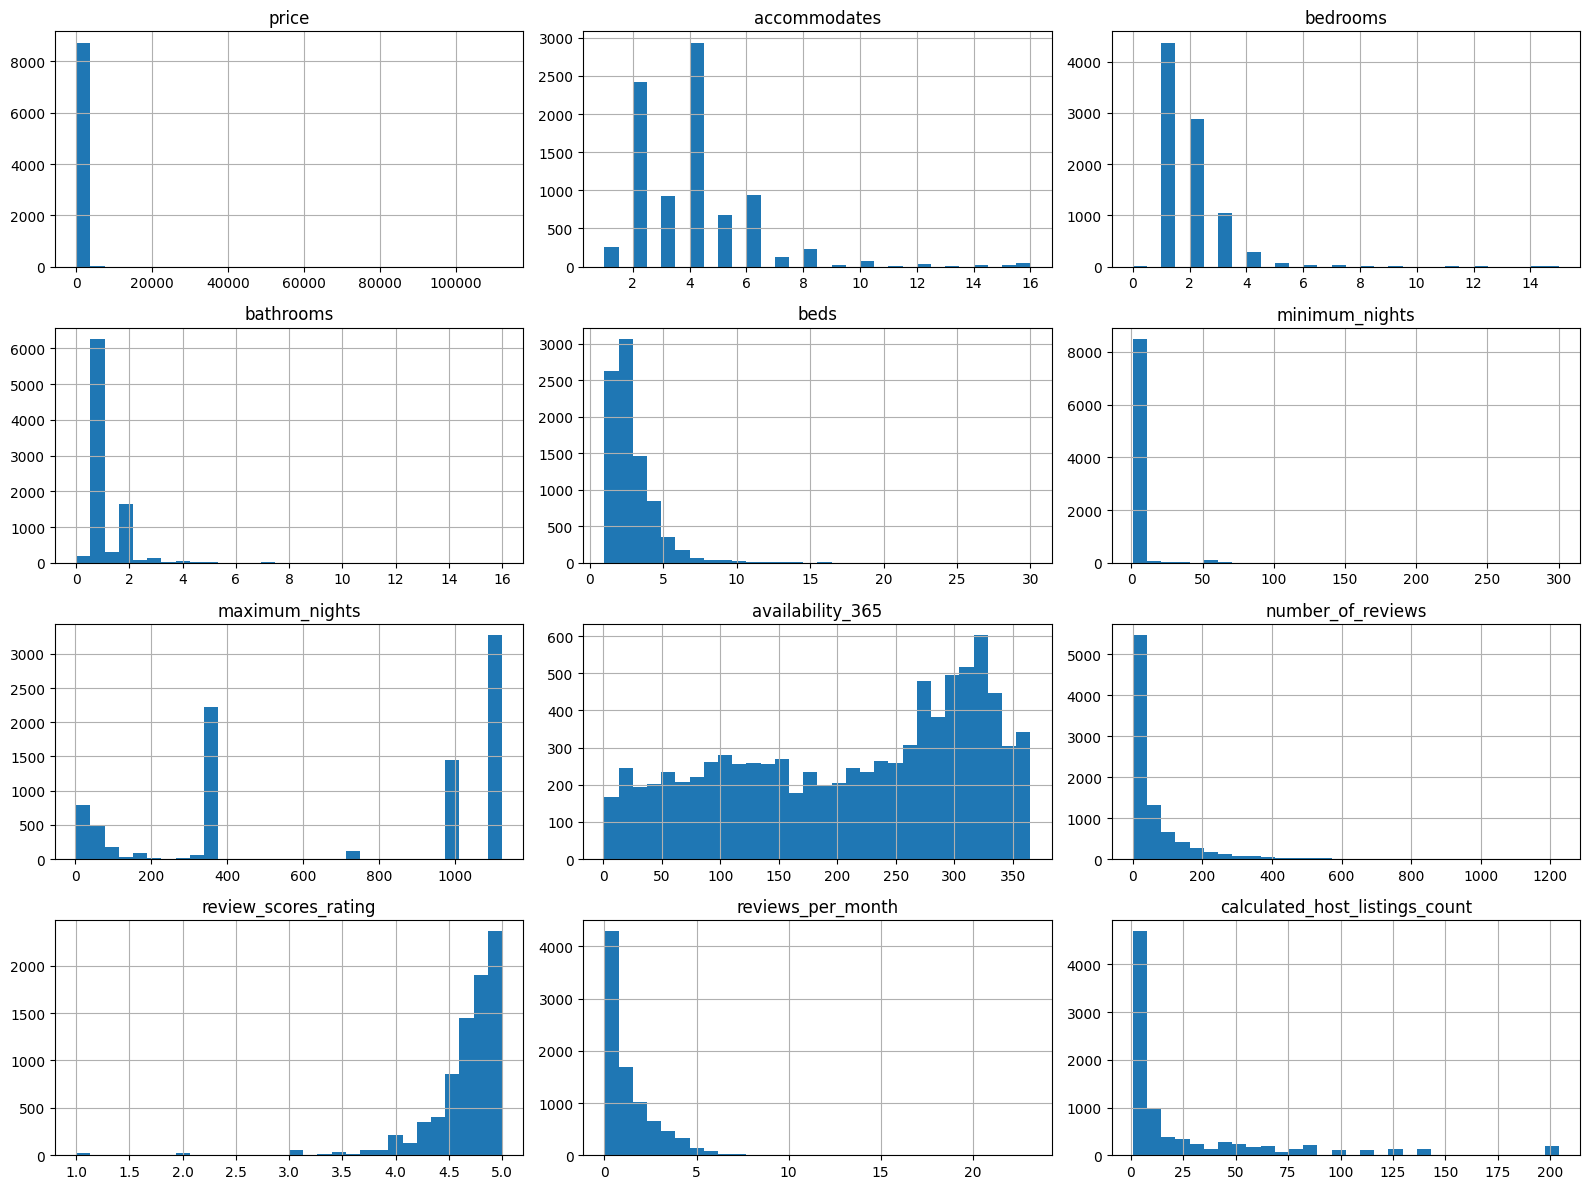

In [38]:
df[num_vars].hist(bins=30, figsize=(16, 12))
plt.tight_layout()

## 8. Outliers

Detección y tratamiento de valores extremos que puedan distorsionar el análisis.

### 8.1 Método: rango intercuartílico (IQR)

In [39]:
outlier_summary = []
for c in num_vars:
    q1, q3 = df[c].quantile([0.25, 0.75])
    iqr = q3 - q1
    low, high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_outliers = ((df[c] < low) | (df[c] > high)).sum()
    outlier_summary.append({
        "variable": c, "low": low, "high": high,
        "n_outliers": n_outliers, "pct_outliers": round(n_outliers / len(df) * 100, 2),
    })

outlier_summary = pd.DataFrame(outlier_summary).sort_values("pct_outliers", ascending=False)
outlier_summary

,variable,low,high,n_outliers,pct_outliers
11,calculated_host_listings_count,-43.00000,77.00000,1015,11.61
8,number_of_reviews,-95.50000,172.50000,809,9.25
5,minimum_nights,-0.50000,3.50000,758,8.67
0,price,-29.19375,392.65625,670,7.66
9,review_scores_rating,4.06500,5.38500,505,5.78
3,bathrooms,0.25000,2.25000,490,5.60
2,bedrooms,-0.50000,3.50000,423,4.84
10,reviews_per_month,-2.34000,4.54000,318,3.64
4,beds,-2.00000,6.00000,225,2.57
1,accommodates,-2.50000,9.50000,202,2.31


`calculated_host_listings_count` y `number_of_reviews` encabezan la lista, patrón conocido de las otras ciudades. `price` sale con un 7.7%, pero la asimetría de 88.4 vista en la sección 7 es demasiado alta incluso para eso: apunta a que unos pocos valores concretos, no un 7.7% del dataset, son los verdaderos responsables.

### 8.2 Caso concreto: dos precios disuasorios extremos, no mercado real

In [40]:
df.sort_values("price", ascending=False)[["name", "room_type", "accommodates", "number_of_reviews", "price"]].head(10)

,name,room_type,accommodates,number_of_reviews,price
4672,Habitación centro Málaga,Private room,2,5,112069.67
839,APARTEMENT 6/7 PEOPLE IN THE CENTER MALAGA,Entire home/apt,1,0,11991.00
6986,Casa Málaga Rural olias piscina y parking,Entire home/apt,10,0,4775.30
4423,Cubo's Mountain Bayview Luxury Villa,Entire home/apt,12,0,4573.50
9196,"Premium Family Villa, Private Pool & Amenities",Entire home/apt,10,0,4452.00
2571,Luxurious home in Málaga,Entire home/apt,13,9,3331.00
6654,"Suites con baño, piscina, Málaga",Private room,16,0,3196.00
1620,Apartamento Palma,Entire home/apt,6,4,2859.80
4020,Villa el Cerrillo Málaga - Churriana by Rurali...,Entire home/apt,12,1,2486.50
9030,Rincon de la Sonrisa frente a la Playa,Entire home/apt,3,0,2360.00


Dos filas se despegan del resto por un margen enorme:
- **"Habitación centro Málaga"**: `Private room` para 2 personas a **112.069,67 €/noche**.
- **"APARTEMENT 6/7 PEOPLE IN THE CENTER MALAGA"**: `Entire home/apt` a **11.991 €/noche** — y con `accommodates = 1`, pese a que el propio título anuncia capacidad para "6/7 people": ni siquiera el dato de capacidad es consistente con el anuncio real.

A diferencia de Valencia (un valor repetido en 19 anuncios de un mismo host), aquí son dos valores **únicos y aislados**: el hueco hasta la siguiente fila más cara (4775,30€, una villa rural con piscina) es de más de 7.200€. Se comprueba `price_quote_raw` para las dos, que trae el detalle de la cotización consultada en el scraping.

In [41]:
import json

for pid in [908030524200905295, 20882292]:
    row = df.loc[df["id"] == pid].iloc[0]
    quote = json.loads(row["price_quote_raw"])["quote"]
    print(row["name"], "-> total:", quote["total_price"], " price_per_night:", quote["price_per_night"])

Habitación centro Málaga -> total: 336209  price_per_night: 112069.6666666666666666666667
APARTEMENT 6/7 PEOPLE IN THE CENTER MALAGA -> total: 23982  price_per_night: 11991


Ambos precios son internamente consistentes (`price_per_night` cuadra con `price` y con `total_price`), no son errores de parseo. Es el mismo patrón de "precio disuasorio" ya visto en Valencia: en vez de bloquear el calendario, el host sube el precio a un valor absurdo para que la fecha quede técnicamente "disponible" pero de facto "no reservable" — ambas filas, además, tienen 5 o 0 reseñas, coherente con anuncios que apenas reciben reservas reales a ese precio. Se descartan las dos filas (0.02% del dataset): la variable clave no se "corrige" inventando un valor, se elimina la fila, igual que con los nulos de `price` en la sección 4.

In [42]:
artifact_ids = [908030524200905295, 20882292]
df = df[~df["id"].isin(artifact_ids)]
df.shape

(8742, 77)

### 8.3 ¿Hay también un error de captura como en Valencia?

En Valencia apareció un anuncio con `bedrooms=beds=bathrooms` idénticos y anormalmente altos a la vez (estadísticas de todo el edificio copiadas en una fila). Se comprueba si Málaga tiene el mismo patrón.

In [43]:
cols = ["name", "room_type", "accommodates", "bedrooms", "beds", "bathrooms", "price"]
error_mask = (df["bedrooms"] >= 6) & (df["beds"] >= 6) & (df["bathrooms"] >= 6)
df.loc[error_mask, cols]

,name,room_type,accommodates,bedrooms,beds,bathrooms,price
364,Large villa · Private pool · Parking · Sleeps 21,Entire home/apt,16,11.0,18.0,6.0,1176.00
443,Homeclub | Awesome Villa w/pool and sea views,Entire home/apt,12,6.0,8.0,7.0,1046.40
496,Old Cottage/ Farmhouse Casas Viejas,Entire home/apt,16,11.0,17.0,6.5,1027.50
587,August Villa Málaga. Relax Playa Piscina Cowor...,Entire home/apt,15,8.0,15.0,7.0,785.00
682,"Luxury Villa 300m to Beach, Private Pool & BBQ",Entire home/apt,12,6.0,6.0,6.0,1020.00
846,Villa Las Yedras. Malaga city,Entire home/apt,16,15.0,25.0,9.5,1141.50
2103,Vistas a la bahía de Málaga desde una villa única,Entire home/apt,15,8.0,12.0,6.0,1426.50
2224,Sleeps 24 with fabulous sea and mountain views,Entire home/apt,16,12.0,19.0,8.5,1650.00
2571,Luxurious home in Málaga,Entire home/apt,13,7.0,21.0,6.5,3331.00
3324,HOSTAL ENTERO x GRUPO C/Lagunillas CENTRO 1kmP...,Entire home/apt,16,7.0,11.0,7.0,571.00


A diferencia de Valencia, aquí las coincidencias son villas de lujo reales (`accommodates` de 10-16, nombres como "Luxury Villa"/"Villa Pinares..."), consistentes con casas grandes con piscina y varias habitaciones: no hay ningún indicio de error de captura. No se corrige nada.

### 8.4 Visualización

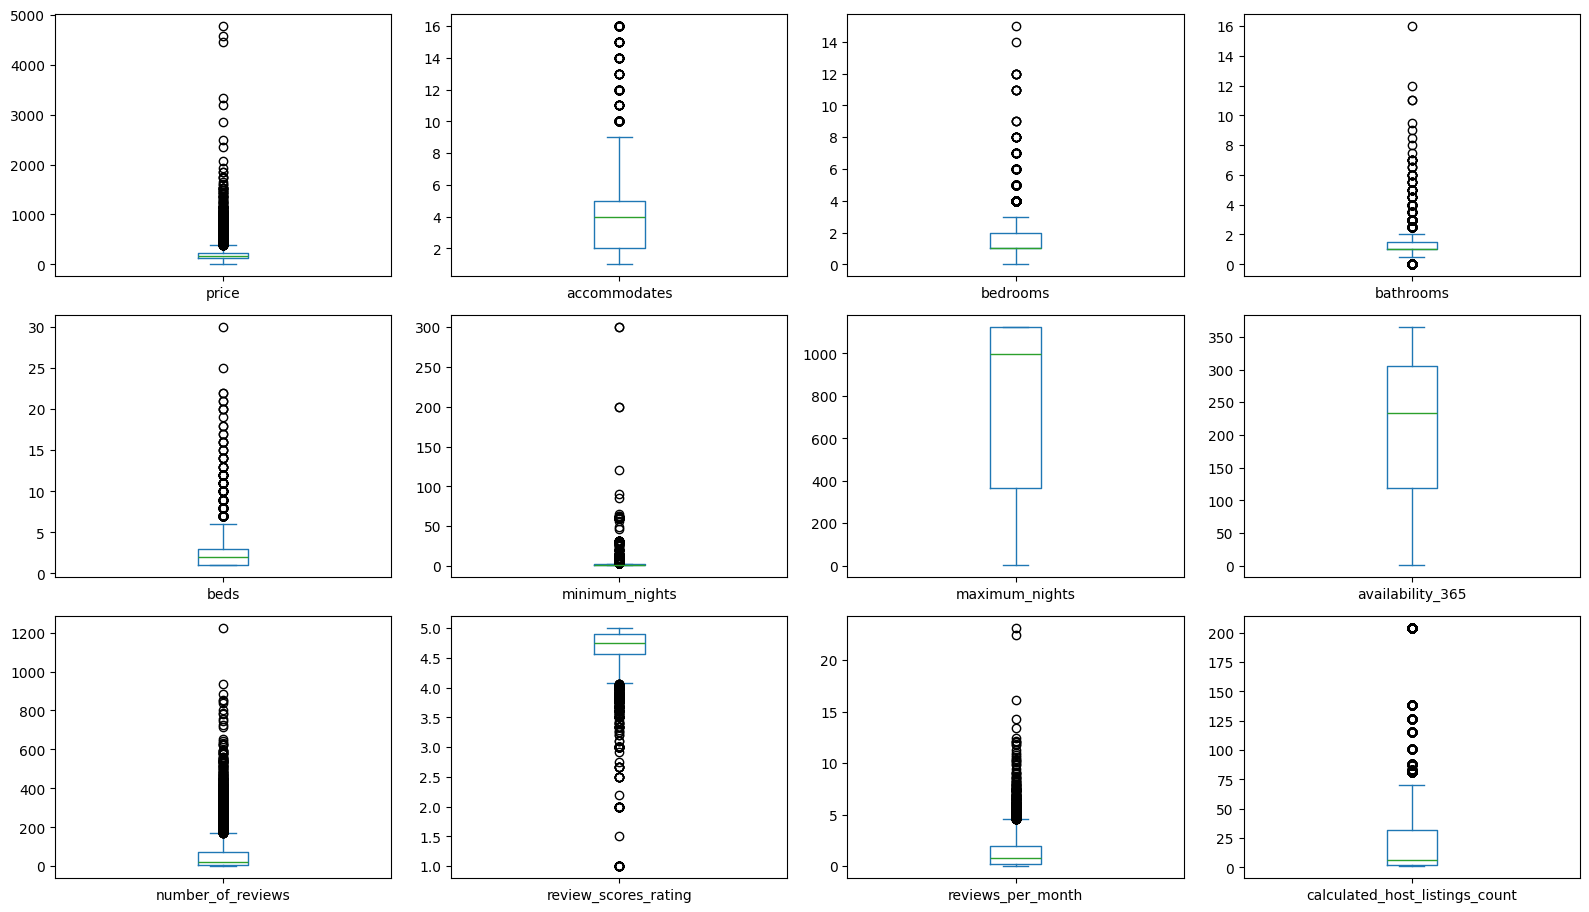

In [44]:
df[num_vars].plot(kind="box", subplots=True, layout=(4, 4), figsize=(16, 12))
plt.tight_layout()

### 8.5 El precio de limpiar bien: la correlación con `price` mejora, y mucho

Se comprueba el efecto de haber quitado solo esas 2 filas: se compara la correlación de las variables de tamaño con `price` antes y después.

In [45]:
size_vars = ["accommodates", "bedrooms", "bathrooms", "beds"]
for c in size_vars:
    print(f"{c}: pearson={df['price'].corr(df[c]):.2f}  spearman={df['price'].corr(df[c], method='spearman'):.2f}")

accommodates: pearson=0.50  spearman=0.61
bedrooms: pearson=0.45  spearman=0.50
bathrooms: pearson=0.45  spearman=0.39
beds: pearson=0.42  spearman=0.51


`accommodates` pasa de **0.07 a 0.50** de Pearson solo por quitar 2 filas (0.02% del dataset) — el salto más grande visto en las cuatro ciudades, y confirma que la asimetría (88.4) de la sección 7 tenía nombre y apellido: esas 2 filas concretas, no una cola larga difusa. Spearman apenas se mueve (0.60 antes y después): al ser un estadístico de rangos, ya era robusto frente a 2 valores puntuales tan extremos.

### 8.6 Conclusión y tratamiento

Con la única corrección necesaria ya aplicada (2 filas de precio-artefacto descartadas), **no se recorta nada más por IQR**: el resto de "outliers" (`calculated_host_listings_count`, `number_of_reviews`, la cola alta de `price` que queda —villas reales de hasta ~4800€—, las notas bajas de `review_scores_rating`) son variabilidad real del mercado, no errores. Las transformaciones para modelar (logs, etc.) se dejan para feature engineering.

## 9. Agrupaciones

#### `neighbourhood_cleansed` / `room_type` (repaso rápido)

In [46]:
df.groupby("neighbourhood_cleansed")["price"].agg(["count", "mean", "median"]).sort_values("median", ascending=False)

,count,mean,median
neighbourhood_cleansed,,,
Campanillas,21,398.712857,259.300
Palma-Palmilla,203,213.350197,196.000
Churriana,124,386.084758,194.100
Este,826,286.463329,182.295
Teatinos-Universidad,69,190.759130,173.640
Centro,5902,209.896322,171.000
Carretera de Cadiz,831,193.952130,165.000
Cruz de Humilladero,373,169.061743,151.650
Puerto de la Torre,32,254.847813,149.335


`Campanillas` encabeza por mediana (259€), pero con solo 21 anuncios: zona de fincas/villas rurales en las afueras, no un polo turístico. `Centro`, con el 67.5% del dataset, se queda en mitad de la tabla (171€ de mediana) — no es la zona más cara, solo la más numerosa. `Ciudad Jardin` cierra la tabla (111€), un patrón muy distinto al de Barcelona/Valencia, donde el distrito más caro suele coincidir con el centro histórico.

### 9.1 Tamaño: `accommodates`, `bedrooms`, `bathrooms`, `beds`

In [47]:
df.groupby("bedrooms")["price"].agg(["count", "median"])

,count,median
bedrooms,,
0.0,1,108.000
1.0,4375,142.650
2.0,2890,190.000
3.0,1053,249.330
4.0,276,326.145
5.0,66,645.000
6.0,33,704.290
7.0,23,809.500
8.0,10,603.530


Relación creciente y monótona hasta 7 dormitorios: 1 → 143€, 2 → 190€, 3 → 249€, 4 → 326€, 5 → 645€, 6 → 704€, 7 → 810€. A partir de 8 dormitorios la muestra es demasiado pequeña (menos de 10 anuncios por valor) para sacar conclusiones fiables.

(0.0, 1500.0)

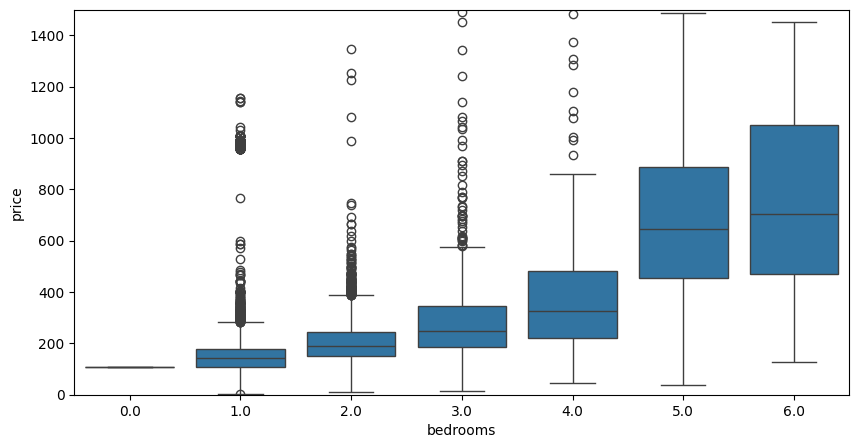

In [48]:
plt.figure(figsize=(10, 5))
sns.boxplot(data=df[df["bedrooms"] <= 6], x="bedrooms", y="price")
plt.ylim(0, 1500)

Se limita a ≤6 dormitorios (a partir de ahí la muestra es demasiado pequeña para que la caja tenga sentido) y a precios ≤1500€ para que el eje Y no quede aplastado por la cola alta ya identificada en la sección 8.

### 9.2 Calidad: `review_scores_rating`

In [49]:
df["price"].corr(df["review_scores_rating"]), df["price"].corr(df["review_scores_rating"], method="spearman")

(np.float64(0.09700767225961086), np.float64(0.1196619901830664))

Correlación débil (Pearson 0.10, Spearman 0.12), algo más alta que en Barcelona/Valencia pero lejos de ser un factor relevante: la nota media apenas explica el precio.

### 9.3 `has_license`

In [50]:
df.groupby("has_license")["price"].agg(["count", "mean", "median"])

,count,mean,median
has_license,,,
False,598,177.769883,142.375
True,8144,217.531008,170.500


Diferencia visible en mediana (170.50€ con licencia vs. 142.38€ sin ella), pero mucho más moderada que en Valencia (donde era casi el doble). Se comprueba dentro de `room_type`, por si la diferencia bruta viene solo del tipo de alojamiento.

In [51]:
df.groupby(["room_type", "has_license"])["price"].median()

room_type        has_license
Entire home/apt  False           174.25
                 True            178.00
Hotel room       False           165.00
                 True           1142.00
Private room     False            70.00
                 True             74.00
Shared room      False            62.50
                 True             61.00
Name: price, dtype: float64

Dentro de `Entire home/apt` la diferencia casi desaparece (178€ con licencia vs. 174,25€ sin ella): a diferencia de Valencia, en Málaga `has_license` no parece ser un factor de precio relevante por sí mismo, la diferencia bruta de antes venía sobre todo de qué `room_type` predomina en cada grupo.

### 9.4 `host_is_superhost`

In [52]:
df.groupby("host_is_superhost")["price"].agg(["count", "mean", "median"])

,count,mean,median
host_is_superhost,,,
False,5750,222.745358,169.450
True,2992,199.563205,168.465


Diferencia mínima (mediana 169.33€ vs. 168.47€): ser Superhost no pesa en el precio, igual que en las otras tres ciudades.

### 9.5 `property_type` (más granular que `room_type`)

In [53]:
top_property_types = df["property_type"].value_counts().head(10).index
df[df["property_type"].isin(top_property_types)].groupby("property_type")["price"].median().sort_values(ascending=False)

property_type
Entire villa                   810.250
Entire home                    249.500
Entire vacation home           190.000
Entire serviced apartment      178.000
Entire rental unit             176.700
Entire condo                   169.330
Entire loft                    140.165
Room in hotel                  116.000
Private room in home            70.500
Private room in rental unit     59.000
Name: price, dtype: float64

`Entire villa` destaca con fuerza (810€ de mediana), muy por encima del resto — coherente con el hallazgo de `Campanillas` en el repaso geográfico. `Entire rental unit`, la categoría dominante (73.4% del dataset), se queda en 177€, cerca de la mediana general.

En conjunto, esta sección apunta en la misma dirección que las otras tres ciudades: **el tamaño manda**, pero aquí `has_license` y `host_is_superhost` pesan bastante menos que en Valencia. La sección 12 añade una tercera pieza al margen del tamaño: la piscina, en amenities.

## 10. Correlación y visualización

### 10.1 Correlación con `price`

In [54]:
corr_vars = num_vars + ["has_license", "host_is_superhost"]
df[corr_vars].corr(numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
accommodates                      0.501306
bedrooms                          0.449404
bathrooms                         0.448488
beds                              0.424122
calculated_host_listings_count    0.162866
availability_365                  0.109309
review_scores_rating              0.097008
has_license                       0.049594
maximum_nights                    0.002551
host_is_superhost                -0.054346
minimum_nights                   -0.113677
number_of_reviews                -0.116226
reviews_per_month                -0.149069
Name: price, dtype: float64

`accommodates` (0.50) encabeza con claridad, seguido de `bedrooms`/`bathrooms`/`beds` (0.42-0.45): el patrón de tamaño de la sección 8.5, ya sin los 2 artefactos. `number_of_reviews`/`reviews_per_month` salen en negativo, un efecto conocido: los anuncios más caros suelen rotar menos huéspedes al año y por tanto acumulan menos reseñas.

In [55]:
df[corr_vars].corr(method="spearman", numeric_only=True)["price"].sort_values(ascending=False)

price                             1.000000
accommodates                      0.607428
beds                              0.511001
bedrooms                          0.503811
bathrooms                         0.388699
calculated_host_listings_count    0.158386
review_scores_rating              0.119662
has_license                       0.105630
availability_365                  0.093359
maximum_nights                    0.070327
host_is_superhost                -0.002758
number_of_reviews                -0.098639
reviews_per_month                -0.138418
minimum_nights                   -0.148201
Name: price, dtype: float64

Con Spearman el orden se mantiene pero las magnitudes suben (`accommodates` 0.61, `beds` 0.51): la cola alta que queda (villas reales de hasta ~4800€, sección 8.6) sigue empujando algo la correlación lineal hacia abajo.

### 10.2 Heatmap

<Axes: >

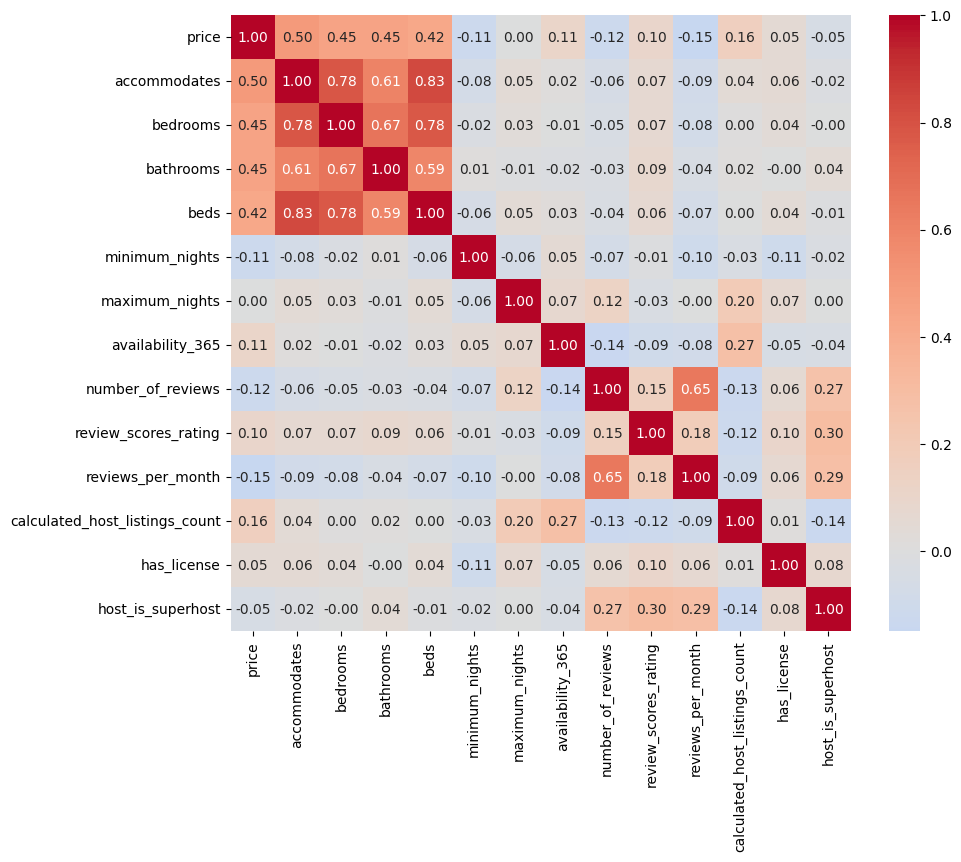

In [56]:
plt.figure(figsize=(10, 8))
sns.heatmap(df[corr_vars].corr(numeric_only=True), annot=True, fmt=".2f", cmap="coolwarm", center=0)

`accommodates`/`bedrooms`/`beds`/`bathrooms` están muy correlacionadas entre sí (miden aspectos del mismo concepto: tamaño), algo a vigilar en un modelo lineal por multicolinealidad.

### 10.3 Pairplot

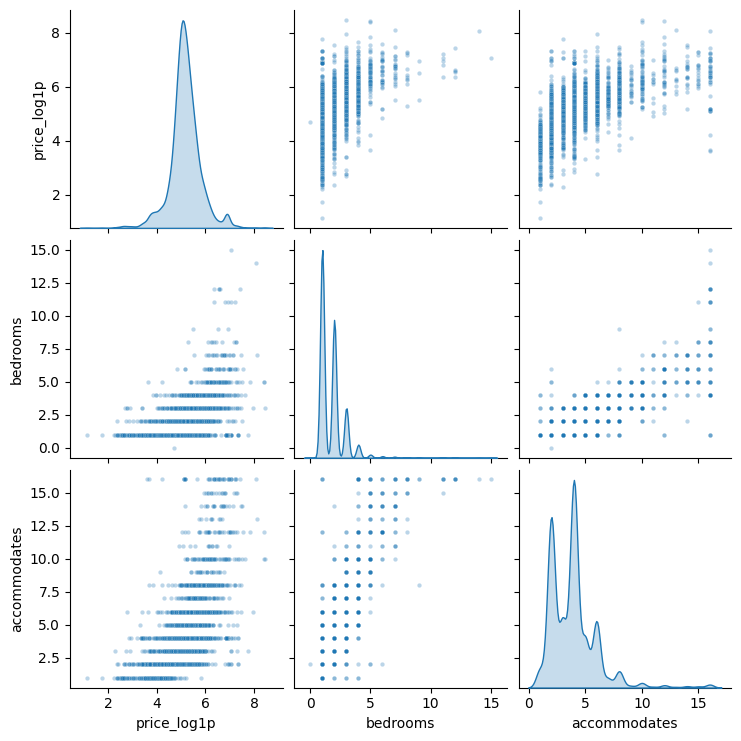

In [57]:
pairplot_data = df[["price", "bedrooms", "accommodates"]].copy()
pairplot_data["price_log1p"] = np.log1p(pairplot_data["price"])
sns.pairplot(pairplot_data[["price_log1p", "bedrooms", "accommodates"]], diag_kind="kde", plot_kws={"alpha": 0.3, "s": 10})

Se ve la relación creciente entre `price_log1p` y ambas variables, sin ya ningún punto disparado gracias a la limpieza de la sección 8.

## 11. Análisis geográfico

Visualización espacial de los anuncios (latitud/longitud) para detectar patrones de precio o densidad por zona. Sin nivel de distrito por encima de `neighbourhood_cleansed` (sección 2), el análisis aquí es de un único nivel, no dos como en Barcelona/Madrid/Valencia.

### 11.1 Rango de coordenadas

In [58]:
df[["latitude", "longitude"]].describe().loc[["min", "max"]]

,latitude,longitude
min,36.646012,-4.58237
max,36.881336,-4.27852


Rango coherente con el término municipal de Málaga (lat ~36.65-36.88, long ~-4.58 a -4.28): un área bastante extensa de norte a sur, reflejo de que distritos como `Puerto de la Torre` y `Campanillas` (sección 9) se extienden lejos del centro. Sin sorpresas.

### 11.2 Distribución espacial por zona

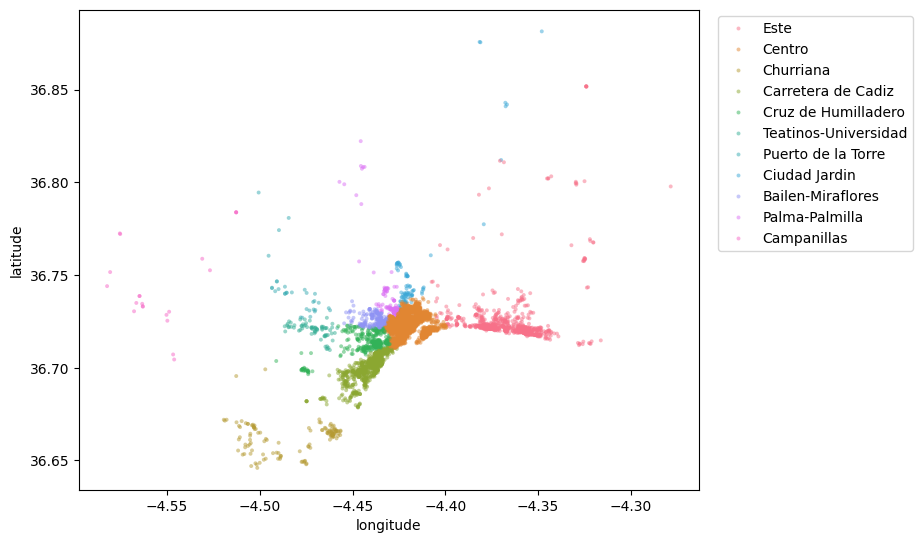

In [59]:
plt.figure(figsize=(8, 8))
sns.scatterplot(
    data=df, x="longitude", y="latitude", hue="neighbourhood_cleansed",
    s=8, alpha=0.5, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.legend(bbox_to_anchor=(1.02, 1), loc="upper left")

Los 11 distritos forman regiones geográficas compactas, confirmando que `neighbourhood_cleansed` está bien asignado. `Centro` (67.5% del dataset) ocupa una porción visualmente pequeña del mapa pero concentra casi todos los puntos: el resto del término municipal, mucho más extenso en superficie, tiene relativamente pocos anuncios.

### 11.3 Precio en el mapa

Text(0, 0.5, 'latitude')

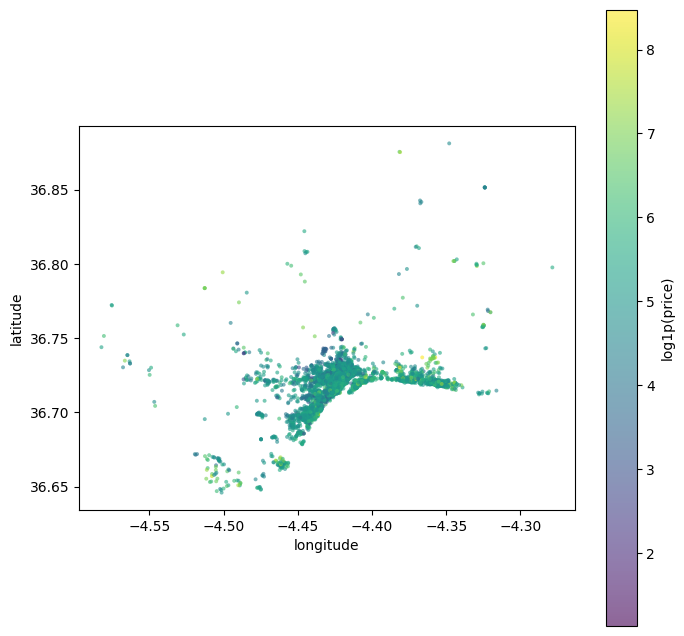

In [60]:
plt.figure(figsize=(8, 8))
sc = plt.scatter(
    df["longitude"], df["latitude"],
    c=np.log1p(df["price"]), cmap="viridis",
    s=8, alpha=0.6, linewidth=0,
)
plt.gca().set_aspect("equal")
plt.colorbar(sc, label="log1p(price)")
plt.xlabel("longitude")
plt.ylabel("latitude")

Sin un patrón centro-periferia tan nítido como en las otras ciudades: los tonos más claros aparecen salpicados en las villas de las afueras (`Campanillas`, zonas altas), coherente con el hallazgo de la sección 9 de que `Centro` no es el distrito más caro.

### 11.4 ¿Dónde están los anuncios grandes?

In [61]:
df.loc[df["bedrooms"] >= 6, "neighbourhood_cleansed"].value_counts()

neighbourhood_cleansed
Este                   32
Centro                 28
Churriana              11
Ciudad Jardin           4
Palma-Palmilla          2
Puerto de la Torre      2
Cruz de Humilladero     1
Carretera de Cadiz      1
Name: count, dtype: int64

De los anuncios con 6+ dormitorios, la mayoría se reparte entre `Este` y `Centro`, sin una concentración tan marcada como el 75% de Barcelona en `Eixample`.

### 11.5 Densidad de anuncios cercanos

`distance_to_center_km` (que se construirá en feature engineering) mide la distancia a un único punto de referencia, pero no captura si un anuncio está en un tramo con mucha oferta de Airbnb alrededor. Se cuenta, para cada anuncio, cuántos otros anuncios reales hay en un radio de 150 metros (con `BallTree` y distancia haversine).

In [62]:
from sklearn.neighbors import BallTree

coords_rad = np.radians(df[["latitude", "longitude"]].to_numpy())
tree = BallTree(coords_rad, metric="haversine")
EARTH_R_KM = 6371
radius_m = 150
counts = tree.query_radius(coords_rad, r=(radius_m / 1000) / EARTH_R_KM, count_only=True)
n_nearby_150m = counts - 1  # excluir el propio anuncio

pd.Series(n_nearby_150m, name="n_nearby_150m").describe()

count    8742.000000
mean      162.377717
std       153.482888
min         0.000000
25%        34.000000
50%       101.000000
75%       302.000000
max       533.000000
Name: n_nearby_150m, dtype: float64

In [63]:
pd.Series(n_nearby_150m, index=df.index, name="n_nearby_150m").corr(df["price"])

np.float64(0.005053270243621141)

Prácticamente cero, a diferencia de Barcelona/Valencia (donde era positiva y modesta): tiene sentido con lo ya visto en esta sección — la zona con más densidad de anuncios (`Centro`) no es la más cara, así que "más anuncios cerca" no viene acompañado aquí de "zona más cara". Candidata más débil para feature engineering que en las otras ciudades, pero se mantiene por consistencia entre modelos.

## 12. Amenities

En la sección 6.1 `amenities` se clasificó como "cuasi-identificador de texto libre". Antes de decidir qué construir con ella, se cuantifica: qué forma tiene, cuánta variedad real hay, y si alguna señal derivada correlaciona con `price`.

### 12.1 Formato y cardinalidad

In [64]:
import ast
from collections import Counter

amenities_parsed = df["amenities"].apply(ast.literal_eval)
n_amenities = amenities_parsed.apply(len)

print("nulos:", df["amenities"].isna().sum())
n_amenities.describe()

nulos: 0


count    8742.000000
mean       33.751773
std        13.778559
min         0.000000
25%        25.000000
50%        34.000000
75%        43.000000
max        95.000000
Name: amenities, dtype: float64

Sin nulos, media de ~34 amenities por anuncio (mediana 34), de 0 a 95. Se comprueba cuántos valores distintos hay en total.

In [65]:
amenity_counter = Counter()
for lst in amenities_parsed:
    amenity_counter.update(lst)

n_once = sum(1 for c in amenity_counter.values() if c == 1)
print("valores distintos de amenity:", len(amenity_counter))
print(f"aparecen una sola vez: {n_once} de {len(amenity_counter)} ({n_once / len(amenity_counter):.0%})")

valores distintos de amenity: 2100
aparecen una sola vez: 1184 de 2100 (56%)


Más de 2000 valores distintos, y más de la mitad aparece en un único anuncio: la misma cola larguísima ya vista en las otras ciudades. Un one-hot directo es inviable.

### 12.2 Top amenities y el problema de la fragmentación

In [66]:
pd.Series(dict(amenity_counter.most_common(12)), name="n_anuncios")

Kitchen                  8200
Wifi                     8058
Hair dryer               7572
Hot water                7334
Iron                     7192
Dishes and silverware    7144
Bed linens               6974
Microwave                6909
Hangers                  6882
Refrigerator             6656
Cooking basics           6394
Essentials               6323
Name: n_anuncios, dtype: int64

Las más comunes (`Kitchen`, `Wifi`, `Hair dryer`...) están en el 75-95% de los anuncios: casi universales, poco discriminantes. Un mismo concepto también se escribe de varias formas:

In [67]:
ac_variants = [k for k in amenity_counter if "air condition" in k.lower()]
{v: amenity_counter[v] for v in sorted(ac_variants, key=lambda k: -amenity_counter[k])}

{'Air conditioning': 5891,
 'Central air conditioning': 900,
 'Portable air conditioning': 63}

Tres variantes distintas para "tiene aire acondicionado", igual que en las otras ciudades. Hace falta agrupar por palabra clave, no tomar los valores tal cual.

### 12.3 Candidatas para feature engineering

In [68]:
def has_any(lst, keywords, exclude=None):
    for item in lst:
        low = item.lower()
        if exclude and any(ex in low for ex in exclude):
            continue
        if any(kw in low for kw in keywords):
            return True
    return False

candidates = pd.DataFrame({
    "n_amenities": n_amenities,
    "has_ac": amenities_parsed.apply(lambda l: has_any(l, ["air condition"])),
    "has_pool": amenities_parsed.apply(lambda l: has_any(l, ["pool"], exclude=["pool table"])),
    "has_dishwasher": amenities_parsed.apply(lambda l: has_any(l, ["dishwasher"])),
})
candidates["price"] = df["price"]

for col in ["n_amenities", "has_ac", "has_pool", "has_dishwasher"]:
    prevalencia = candidates[col].mean() if col == "n_amenities" else candidates[col].mean() * 100
    corr = candidates[col].astype(float).corr(candidates["price"])
    label = f"media={prevalencia:.1f}" if col == "n_amenities" else f"prevalencia={prevalencia:.1f}%"
    print(f"{col:16s} {label:18s} corr con price: {corr:.3f}")

n_amenities      media=33.8         corr con price: 0.018
has_ac           prevalencia=78.3%  corr con price: 0.093
has_pool         prevalencia=8.8%   corr con price: 0.229
has_dishwasher   prevalencia=32.2%  corr con price: 0.158


`has_pool` destaca con fuerza (**0.229**), incluso por encima de Valencia (0.21) — coherente con el hallazgo de la sección 9.5, donde `Entire villa` era la categoría de propiedad más cara con diferencia, y con solo un 8.8% de anuncios con piscina, es un factor claramente diferenciador. `has_dishwasher` (0.158) y `has_ac` (0.093) aportan señal moderada. `n_amenities` en cambio es débil (0.018): tener muchas comodidades en bruto no dice nada sobre el precio si no son las comodidades correctas. Las cuatro se construyen en `02_feature_engineering.ipynb`, con `has_pool` como la candidata más prometedora.

## 13. Conclusiones

Resumen de los principales hallazgos del EDA.

### Limpieza aplicada

De las 9568 filas y 90 columnas originales, tras la limpieza:
- 13 columnas 100% vacías eliminadas (las 12 comunes a las cuatro ciudades + `neighbourhood_group_cleansed`, propia de Málaga).
- `bathrooms` recuperado desde `bathrooms_text`.
- Reviews sin datos por no tener reviews todavía: `reviews_per_month` imputado a 0, el resto se deja como `NaN`/`NaT`.
- `license` convertido en flag `has_license` (93.1% con licencia, la más alta de las cuatro ciudades).
- Filas sin `price` descartadas.
- Columnas de bajo volumen (host/estancia, ~0.1%) descartadas.
- `bedrooms`/`beds` imputados con la mediana por `room_type`.
- `has_availability` eliminada (100% constante).
- Sin duplicados de fila completa ni de `id`; 73 "duplicados lógicos" (mismo edificio/residencia) son anuncios reales distintos.
- **2 filas con precios-artefacto descartadas** (112.069,67€ y 11.991€, ver sección 8.2): mismo patrón de "precio disuasorio" que en Valencia, pero como valores únicos y aislados, no un cluster repetido.
- A diferencia de Valencia, **no se encontró ningún error de captura** en `bedrooms`/`beds`/`bathrooms` (sección 8.3): las coincidencias de valores altos correspondían a villas de lujo reales.

In [69]:
df.shape

(8742, 77)

### Variables nuevas

- `has_license`: flag booleano derivado de `license`.

### El hallazgo principal: el tamaño manda, y la piscina pesa más que en ninguna otra ciudad

- `accommodates` (Pearson 0.50, Spearman 0.61) encabeza con claridad, seguido de `bedrooms`/`bathrooms`/`beds` (0.42-0.51): el patrón de tamaño ya visto en las otras tres ciudades, aquí incluso más marcado.
- Relación `bedrooms` → `price` monótona: 1BR ≈ 143€, 2BR ≈ 190€, 3BR ≈ 249€... hasta 7 dormitorios, ≈810€.
- A diferencia de Valencia, aquí `has_license` (170€ vs. 142€ en bruto, pero la diferencia casi desaparece dentro de `Entire home/apt`) y `host_is_superhost` (169€ vs. 168€) apenas pesan en el precio.
- `review_scores_rating` tampoco explica el precio (correlación ~0.10-0.12), en línea con las otras ciudades.
- Hallazgo propio de Málaga: `has_pool` en amenities correlaciona **0.229** con `price` — más fuerte que en Valencia (0.21), pese a que solo el 8.8% de los anuncios la tiene. `has_dishwasher` (0.158) aporta señal moderada; `has_ac` (0.093) y sobre todo `n_amenities` (0.018) son mucho más débiles: la cantidad bruta de comodidades no importa, la piscina en concreto sí.


### Un artefacto de datos con la misma causa que Valencia, pero distinta forma

- 2 anuncios (0.02% del dataset) con precios de 112.069,67€ y 11.991€/noche resultaron ser el mismo patrón de "precio disuasorio" ya visto en Valencia (el host sube el precio a un valor absurdo en vez de bloquear el calendario), pero aquí como **valores únicos y aislados** por un host distinto cada uno, no un cluster de 19-20 filas idénticas de un solo host.
- Quitar esas 2 filas disparó la correlación de tamaño con `price`: `accommodates` pasó de 0.07 a **0.52** de Pearson, el salto más grande de las cuatro ciudades — la asimetría de 88.4 vista en la sección 7 tenía nombre y apellido: 2 filas concretas.

### Una diferencia estructural: sin jerarquía distrito/barrio

- A diferencia de Barcelona/Madrid/Valencia, Málaga no trae `neighbourhood_group_cleansed`: `neighbourhood_cleansed` (11 valores) es el único nivel geográfico disponible, y hace de distrito y de barrio a la vez.
- Además, `Centro` concentra el 67.5% de todo el dataset, muy por encima de la concentración del distrito más grande en las otras tres ciudades — el resto de zonas tiene muestras bastante más pequeñas.
- Esto afecta directamente a cómo se codificará la ubicación en `02_feature_engineering.ipynb`: con solo 11 categorías (frente a las 10-21 de distrito de las otras ciudades, pero sin nivel de barrio más fino), un one-hot directo por `neighbourhood_cleansed` es plausible, no hará falta el mismo target encoding de barrio ya usado en Barcelona/Madrid/Valencia — decisión que se toma en el siguiente notebook, no aquí.

### De cara al modelado (decisiones diferidas, no aplicadas aquí)

- `accommodates`/`bedrooms`/`beds`/`bathrooms` correlacionadas entre sí: vigilar multicolinealidad en un modelo lineal.
- `property_type` (47 categorías) necesitará agrupar las categorías raras.
- Las familias redundantes de `minimum_nights`/`maximum_nights` y `availability` no se han simplificado, solo diagnosticado.
- `price_quote_*` sigue sin decisión; ya se usó puntualmente en la sección 8 para diagnosticar el artefacto de precio, pero su uso como feature está por evaluar.
- Candidatas a log-transform: `price` (asimetría todavía alta tras la limpieza) y las variables de reviews.
- Cómo codificar `neighbourhood_cleansed` (one-hot directo vs. target encoding) es una decisión abierta para `02_feature_engineering.ipynb`, dada la falta de nivel de distrito.
- `has_pool` es la candidata de amenities con más potencial en Málaga, incluso por encima de Valencia; priorizarla en feature engineering.

## 14. Exportar dataset limpio

Guardar el dataset resultante tras la limpieza en `data/processed/malaga/` para su uso en los siguientes notebooks (feature engineering).

In [70]:
df.to_csv(f"{PROJECT_DIR}/data/processed/malaga/listings_full_clean.csv", index=False)